# Thesis | Project Work
## Advertisement Click Fraud Detection and Prevention

Camilla Alves. Master's Thesis, NOVA IMS (Data-Driven Marketing, 2024).

---

### Summary

Supervised classification of Google Ads clicks as genuine or fraudulent. The dataset contains 13,098 real clicks collected from two clients of a Brazilian marketing agency between January and March 2024. Ground-truth labels come from the Traffic Guardian tool. Five algorithms are compared under the CRISP-DM methodology: SVM, Random Forest, KNN, Gradient Tree Boosting and XGBoost.

The most predictive feature agreed upon by all five models is `Is_primary_click` — whether the click was the first action of the user's session. Aggregate features (`Clicks_per_IP`, `Clicks_per_User_ID`) come second.

Gradient Tree Boosting was chosen as the best model for the balance across accuracy, precision and F1 (SVM edges out the others on recall alone, but GTB leads on the composite picture).


## Business Understanding

The research uses data provided by a Brazilian digital marketing agency for two of its Google Ads clients (A and B). The Traffic Guardian tool pre-classified each click as legitimate (`success`) or fraudulent (`invalid`). The goal is to build a machine learning model that reproduces this classification and, from it, identifies the patterns behind non-genuine clicks so the agency can act on them.

### Dataset description

| Feature | Description |
|---|---|
| `Client` | Client A or B |
| `Timestamp` | Date and time of the click |
| `Campaign_type` | Google Ads campaign type |
| `Connection_type` | Network connection type at the moment of the click |
| `Device_browser` | Browser used on the device |
| `Device_browser_language` | Browser language setting |
| `Device_platform` | Operating system of the device |
| `Device_type` | Device category |
| `Estimated_CPC` | Estimated cost per click |
| `IP_address` | IP of the click origin |
| `User_ID` | UUID for the user |
| `Is_primary_click` | Boolean — whether the click was the user's primary action |
| `Network` | Advertising network |
| `Validation_status` | Target — `success` or `invalid` |


# Data Understanding

## Initializations and data loading

In [1]:
# Loading packages
import warnings
warnings.filterwarnings("ignore")

import collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score,
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from joblib import dump

RANDOM_STATE = 123
DATA_PATH = Path("../data/dataset1.xlsx")
MODEL_DIR = Path("../models"); MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR = Path("../reports"); REPORT_DIR.mkdir(exist_ok=True)

# Consistent visual language across the notebook
FRAUD_COLOR   = "#C0392B"
GENUINE_COLOR = "#2C3E50"
PALETTE       = [GENUINE_COLOR, FRAUD_COLOR]

sns.set_theme(style="whitegrid", context="notebook",
              rc={"axes.spines.top": False, "axes.spines.right": False,
                  "axes.grid.axis": "y", "grid.alpha": 0.25,
                  "axes.titleweight": "semibold", "axes.titlesize": 12,
                  "axes.labelsize": 10})
plt.rcParams["figure.dpi"] = 100


## Initial data exploration

In [2]:
ds = pd.read_excel(DATA_PATH, engine="openpyxl")
ds.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13098 entries, 0 to 13097
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Client                   13098 non-null  object 
 1   Timestamp                13098 non-null  object 
 2   Campaign_type            13098 non-null  object 
 3   Connection_type          13098 non-null  object 
 4   Device_browser           13098 non-null  object 
 5   Device_browser_language  13098 non-null  object 
 6   Device_platform          13098 non-null  object 
 7   Device_type              13098 non-null  object 
 8   Estimated_CPC            13098 non-null  float64
 9   IP_address               13098 non-null  object 
 10  Is_primary_click         13098 non-null  int64  
 11  Network                  13098 non-null  object 
 12  Validation_status        13098 non-null  object 
 13  User_ID                  13098 non-null  object 
dtypes: float64(1), int64(1

In [3]:
ds.head()

,Client,Timestamp,Campaign_type,Connection_type,Device_browser,Device_browser_language,Device_platform,Device_type,Estimated_CPC,IP_address,Is_primary_click,Network,Validation_status,User_ID
0,A,2024-01-15 19:59:10.604 UTC,search,Cable/DSL,Chrome Mobile,pt,Android,HIGH_END_MOBILE,0.0,2804:14c:c0:843a:79c7:3dfe:cd0d:2d43,1,Google search,success,bf9e7977-4178-4fca-8d65-cbc92a95d13a
1,A,2024-01-15 20:02:58.855 UTC,search,Cable/DSL,Chrome Mobile,pt,Android,HIGH_END_MOBILE,0.0,179.35.51.25,1,Google search,success,3e16cc0c-ac80-4e64-b089-2fba740c90ab
2,A,2024-01-15 20:09:18.254 UTC,search,Cable/DSL,Chrome Mobile,pt,Android,HIGH_END_MOBILE,0.0,187.74.98.116,1,Google search,success,15b6c2d5-7674-44a0-a9c2-c49846cee722
3,A,2024-01-15 20:11:30.39 UTC,performance max,Cable/DSL,Chrome Mobile,pt,Android,HIGH_END_MOBILE,0.0,138204208241,1,Cross-network,success,199d8168-0b4e-4da8-bc87-2c7493a2c6ce
4,A,2024-01-15 20:13:06.44 UTC,search,Cable/DSL,Chrome Mobile,pt,Android,HIGH_END_MOBILE,0.0,2804:14c:a1:8a1e:78de:f1c2:361e:c350,1,Google search,success,f26e7a37-474b-4e75-858c-ca3713d32f2b


In [4]:
ds.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Client,13098,2,B,7216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,13098,13070,2024-02-17 19:58:33.436 UTC,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Campaign_type,13098,3,performance max,6383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Connection_type,13098,5,Cable/DSL,10605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Device_browser,13098,34,Chrome Mobile,5558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Device_browser_language,13098,10,pt,12158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Device_platform,13098,10,Android,10790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Device_type,13098,5,HIGH_END_MOBILE,11929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_CPC,13098.0,NaN,NaN,NaN,1.315074,0.742286,0.0,0.84,1.11,1.58,6.0
IP_address,13098,9289,201.77.102.146,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print(ds.isnull().sum())

Client                     0
Timestamp                  0
Campaign_type              0
Connection_type            0
Device_browser             0
Device_browser_language    0
Device_platform            0
Device_type                0
Estimated_CPC              0
IP_address                 0
Is_primary_click           0
Network                    0
Validation_status          0
User_ID                    0
dtype: int64


### Working with the Timestamp variable

In [6]:
ds["Timestamp"] = pd.to_datetime(ds["Timestamp"])
ds["hour"]    = ds["Timestamp"].dt.hour
ds["day"]     = ds["Timestamp"].dt.day
ds["month"]   = ds["Timestamp"].dt.month
ds["weekday"] = ds["Timestamp"].dt.weekday


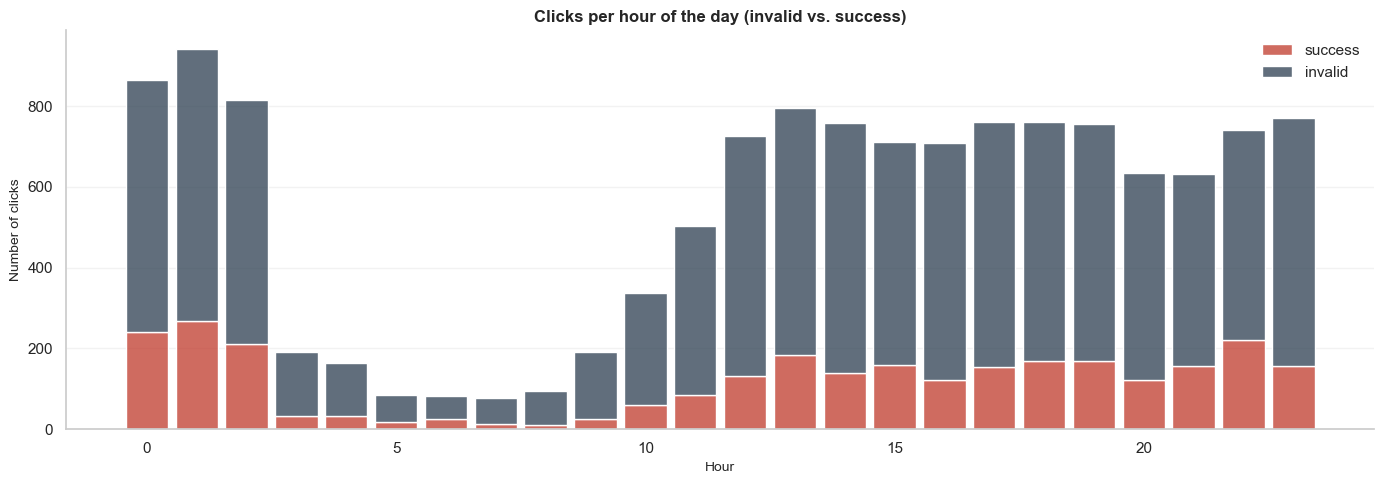

In [7]:
# Clicks per hour of the day
plt.figure(figsize=(14, 5))
sns.histplot(data=ds, x="hour", hue="Validation_status", multiple="stack",
             discrete=True, shrink=0.85, palette=PALETTE, edgecolor="white")
plt.title("Clicks per hour of the day (invalid vs. success)")
plt.xlabel("Hour")
plt.ylabel("Number of clicks")
plt.legend(labels=["success", "invalid"], frameon=False, loc="upper right", title="")
plt.tight_layout()
plt.show()


Click volume varies across the day, with peaks around midnight and between 3pm and 9pm. This mirrors general internet-usage patterns. Comparing the ratio of invalid to valid clicks per hour, there is no strong time-of-day pattern for fraud specifically. The steady presence of invalid clicks even in low-activity hours is consistent with bots or automated programs operating independently from human behaviour.

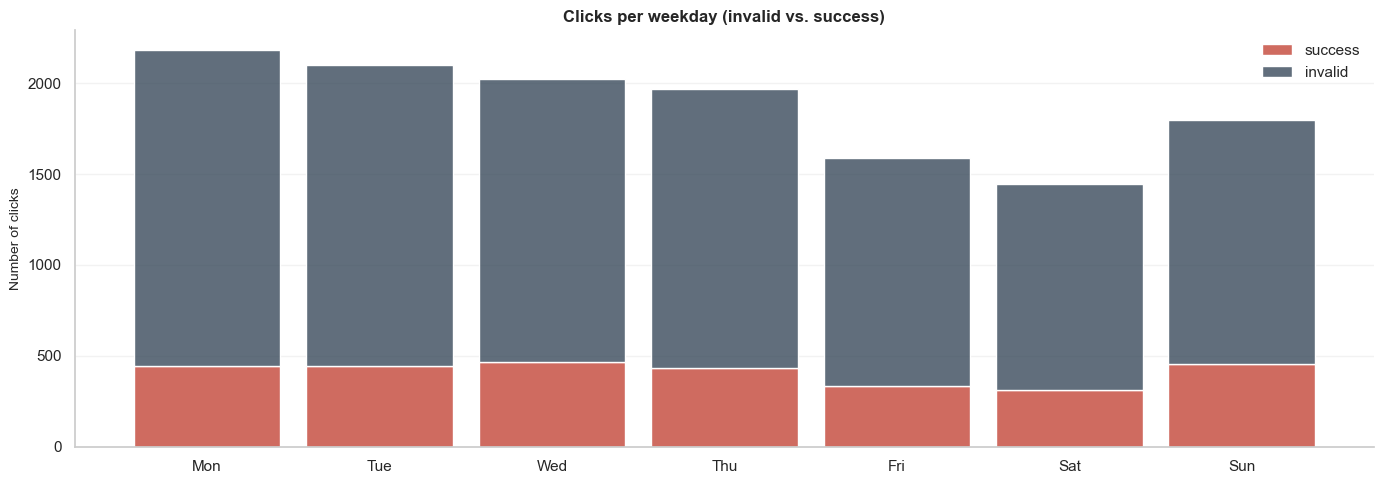

In [8]:
# Clicks per weekday
plt.figure(figsize=(14, 5))
sns.histplot(data=ds, x="weekday", hue="Validation_status", multiple="stack",
             discrete=True, shrink=0.85, palette=PALETTE, edgecolor="white")
plt.title("Clicks per weekday (invalid vs. success)")
plt.xlabel("")
plt.ylabel("Number of clicks")
plt.xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.legend(labels=["success", "invalid"], frameon=False, loc="upper right", title="")
plt.tight_layout()
plt.show()


The gap between valid and invalid clicks is more marked here. Legitimate traffic varies more across the week in response to user behaviour, while fraudsters seem to keep their activity closer to constant.

### Exploration of categorical variables

In [9]:
# Print the fraud rate for each category of each categorical variable
categorical_columns = ["Client", "Campaign_type", "Connection_type", "Device_browser",
                       "Device_browser_language", "Device_platform", "Device_type", "Network"]

for col in categorical_columns:
    print(f"Unique values in {col}:")
    value_counts = ds[col].value_counts(normalize=True)
    for category, count in value_counts.items():
        mask = ds[col] == category
        success_rate = (ds.loc[mask, "Validation_status"] == "success").mean()
        invalid_rate = (ds.loc[mask, "Validation_status"] == "invalid").mean()
        print(f"  {category}: {count:.4f}  success {success_rate:.2%}  invalid {invalid_rate:.2%}")
    print()


Unique values in Client:
  B: 0.5509  success 86.06%  invalid 13.94%
  A: 0.4491  success 67.78%  invalid 32.22%

Unique values in Campaign_type:
  performance max: 0.4873  success 73.74%  invalid 26.26%
  search: 0.4628  success 81.74%  invalid 18.26%
  video: 0.0499  success 81.93%  invalid 18.07%

Unique values in Connection_type:
  Cable/DSL: 0.8097  success 78.30%  invalid 21.70%
  Cellular: 0.1473  success 77.55%  invalid 22.45%
  Corporate: 0.0251  success 70.52%  invalid 29.48%
  (not set): 0.0167  success 68.95%  invalid 31.05%
  Satellite: 0.0012  success 87.50%  invalid 12.50%

Unique values in Device_browser:
  Chrome Mobile: 0.4243  success 85.16%  invalid 14.84%
  Facebook: 0.1849  success 63.96%  invalid 36.04%
  Mobile Safari: 0.0602  success 82.26%  invalid 17.74%
  Instagram App: 0.0526  success 72.71%  invalid 27.29%
  Chrome: 0.0470  success 84.23%  invalid 15.77%
  Samsung Browser: 0.0418  success 78.06%  invalid 21.94%
  Chrome Webview: 0.0383  success 78.69%  inv

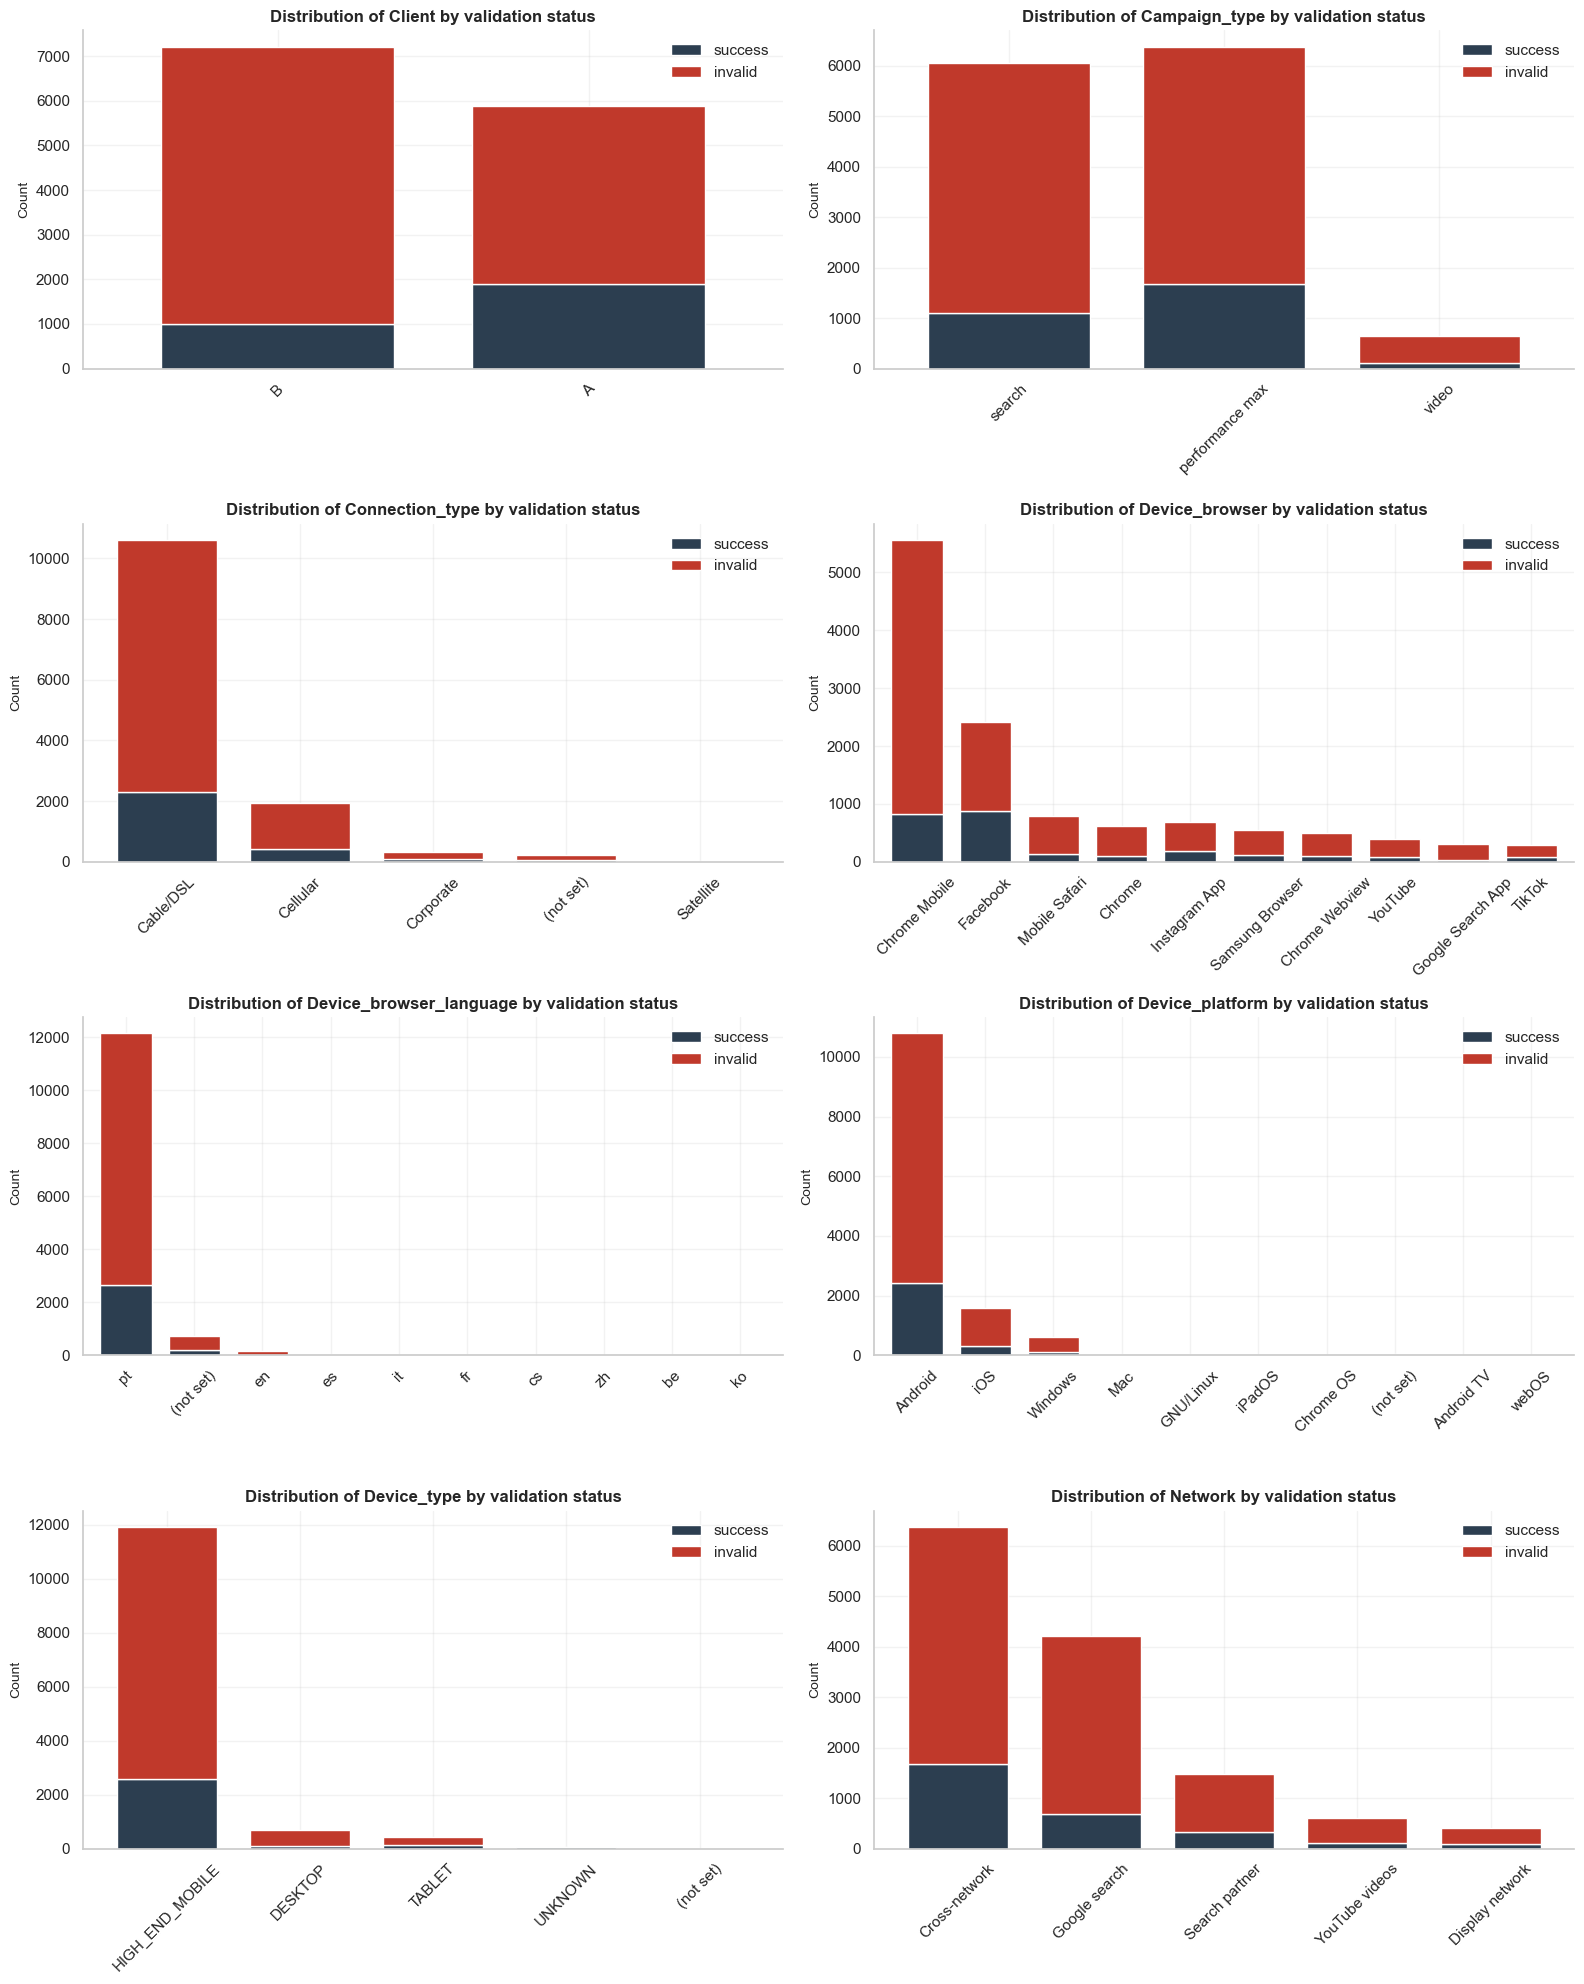

In [10]:
# Distribution of the top 10 categories of each variable, split by validation status
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.ravel()

for i, col in enumerate(categorical_columns):
    crosstab = pd.crosstab(ds[col], ds["Validation_status"])
    top_categories = crosstab.nlargest(10, "success")
    top_categories.plot(kind="bar", stacked=True, ax=axes[i],
                        color=[GENUINE_COLOR, FRAUD_COLOR], width=0.75, edgecolor="white")
    axes[i].set_title(f"Distribution of {col} by validation status")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend(labels=["success", "invalid"], frameon=False, loc="upper right")

plt.tight_layout()
plt.show()


**Client.** Client A shows an invalid-click rate of 32.22% against 13.94% for Client B — more than double. Client A operates in a vertical (healthcare) known to attract aggressive competition and click farms, which fits the pattern.

**Campaign_type.** Performance Max has the highest fraud rate at 26.26%. Search (18.26%) and Video (18.07%) sit close together, well below Performance Max. This is consistent with Performance Max serving Google's broader inventory (partner sites and apps), where traffic quality historically drops.

**Connection_type.** Cable/DSL and Cellular dominate the volume, both close to 22% invalid. Corporate connections and `(not set)` show notably higher rates (29-31%), which is a small but real red flag on top-of-funnel filtering.

**Device_browser.** Chrome Mobile (42.43%) and Facebook (18.49%) carry the bulk of traffic. Facebook stands out with a 36% invalid rate, well above the other high-volume browsers. Long-tail browsers like Google-Read-Aloud (97.67% invalid), Edge WebView (80%), and OkHttp (100%) are obviously bot-driven — small counts, but almost all fraudulent.

**Device_platform.** Android dominates (82.38%, 22.44% invalid). The `(not set)` platform, though tiny (0.34%), is 97.78% fraudulent. Detecting missing platform metadata alone would already catch a chunk of clear fraud.

**Device_type.** HIGH_END_MOBILE covers 91% of traffic with a fraud rate near 22%. TABLET is the highest-fraud legitimate category at 33%. UNKNOWN and `(not set)` types are almost entirely fraudulent (92-100%).

**Network.** Cross-network and Google Search account for the majority of clicks. Fraud rates hover between 16% and 26% across all networks, so this variable adds signal but no single-category smoking gun.


### Exploration of numerical variables

In [11]:
numeric_columns = ds.select_dtypes(include=["float64", "int64"]).columns.tolist()
print(ds[numeric_columns].describe())


       Estimated_CPC  Is_primary_click          hour           day  \
count   13098.000000      13098.000000  13098.000000  13098.000000   
mean        1.315074          0.796305     12.917545     15.558864   
std         0.742286          0.402760      7.377727      9.107953   
min         0.000000          0.000000      0.000000      1.000000   
25%         0.840000          1.000000      8.000000      7.000000   
50%         1.110000          1.000000     14.000000     17.000000   
75%         1.580000          1.000000     19.000000     23.000000   
max         6.000000          1.000000     23.000000     31.000000   

              month       weekday  
count  13098.000000  13098.000000  
mean       2.350359      2.778898  
std        0.841451      2.010693  
min        1.000000      0.000000  
25%        2.000000      1.000000  
50%        2.000000      3.000000  
75%        3.000000      4.000000  
max        4.000000      6.000000  


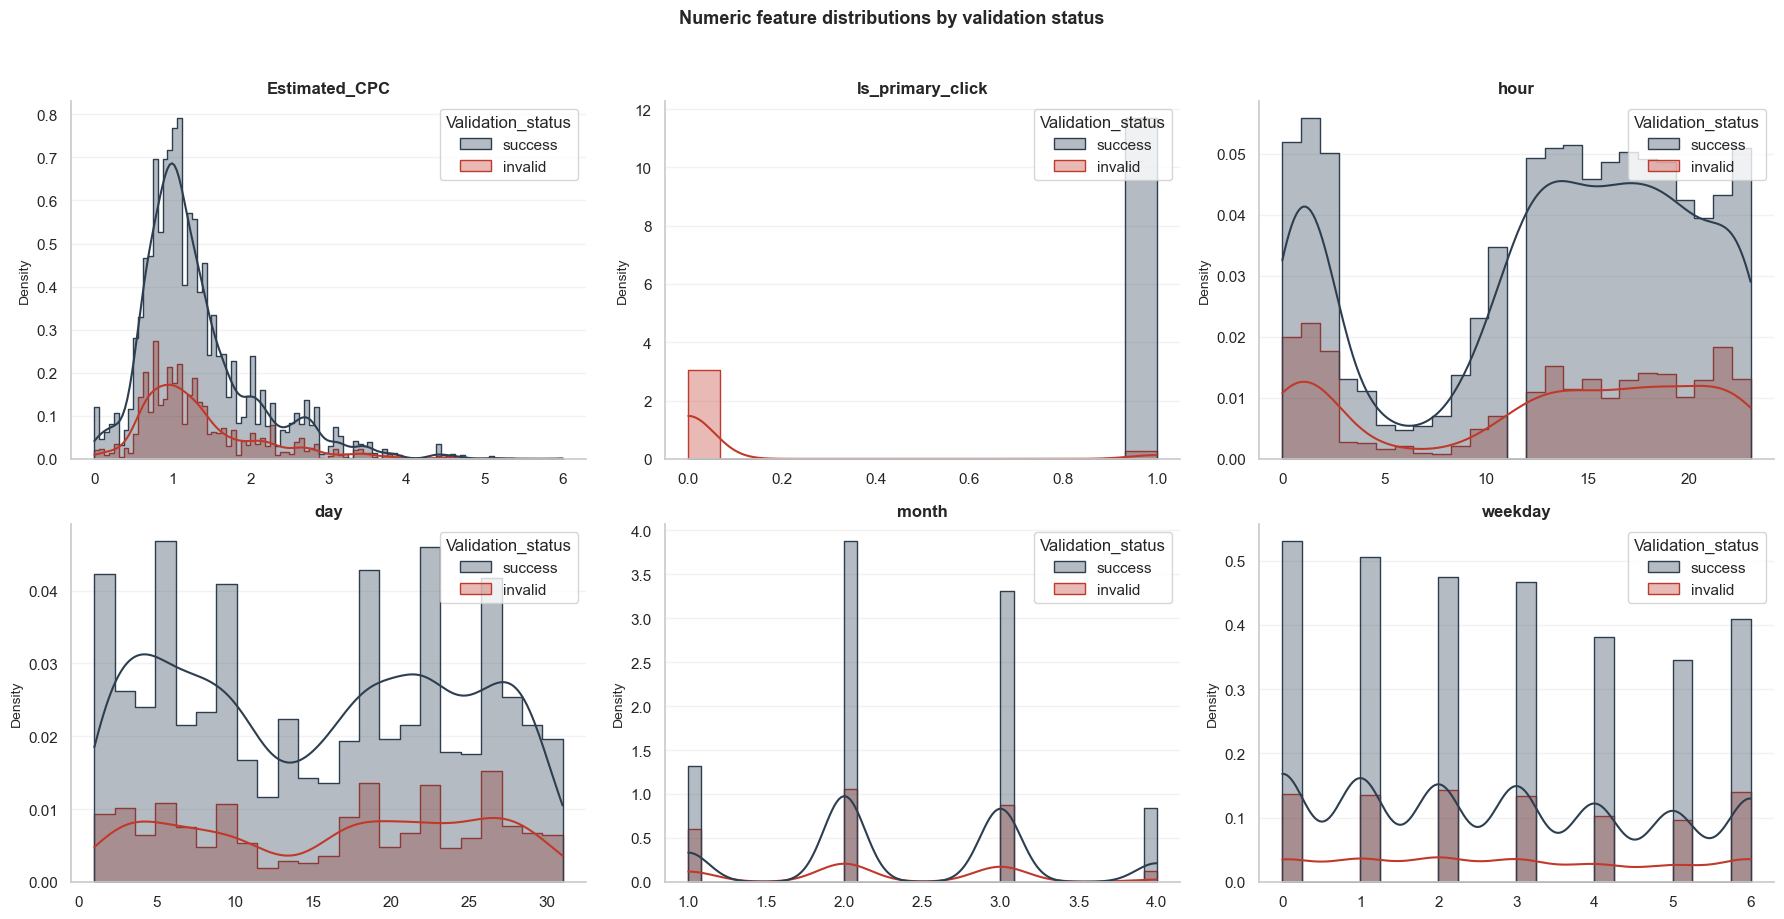

In [12]:
# Histograms of numeric features, split by validation status
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_columns[:6]):
    sns.histplot(ds, x=col, hue="Validation_status", kde=True, ax=axes[i],
                 palette=PALETTE, element="step", stat="density", alpha=0.35)
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel("Density")
    axes[i].set_xlabel("")

plt.suptitle("Numeric feature distributions by validation status", y=1.02, fontsize=13, fontweight="semibold")
plt.tight_layout()
plt.show()


Two features stand out. `Estimated_CPC` is right-skewed, with 50% of clicks between 0.84 and 1.58, and the density of invalid clicks concentrates at the low-cost end. Cheap campaigns are easier targets for automated clicks and typically receive less monitoring.

`Is_primary_click` is a near-binary distribution (about 80% of clicks are primary). Invalid clicks visibly over-index at the value 0 (not primary) — a first clean visual signal that this feature will drive most of the model's predictive power. The other four features (`hour`, `day`, `month`, `weekday`) show similar shapes across success and invalid, meaning they contribute little on their own.


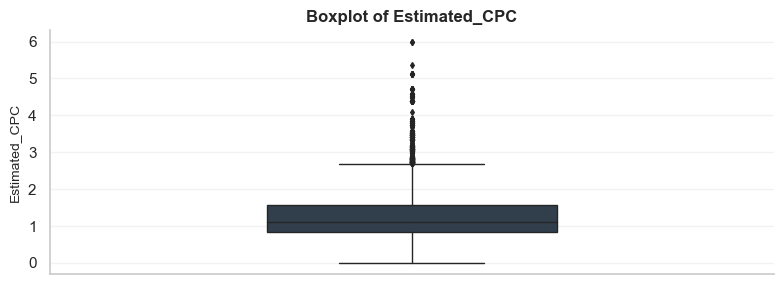

In [13]:
# Boxplot for Estimated_CPC
fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(data=ds, y="Estimated_CPC", ax=ax, color=GENUINE_COLOR, width=0.4,
            fliersize=3, linewidth=1)
ax.set_title("Boxplot of Estimated_CPC")
ax.set_ylabel("Estimated_CPC")
plt.tight_layout()
plt.show()


### Correlation between variables

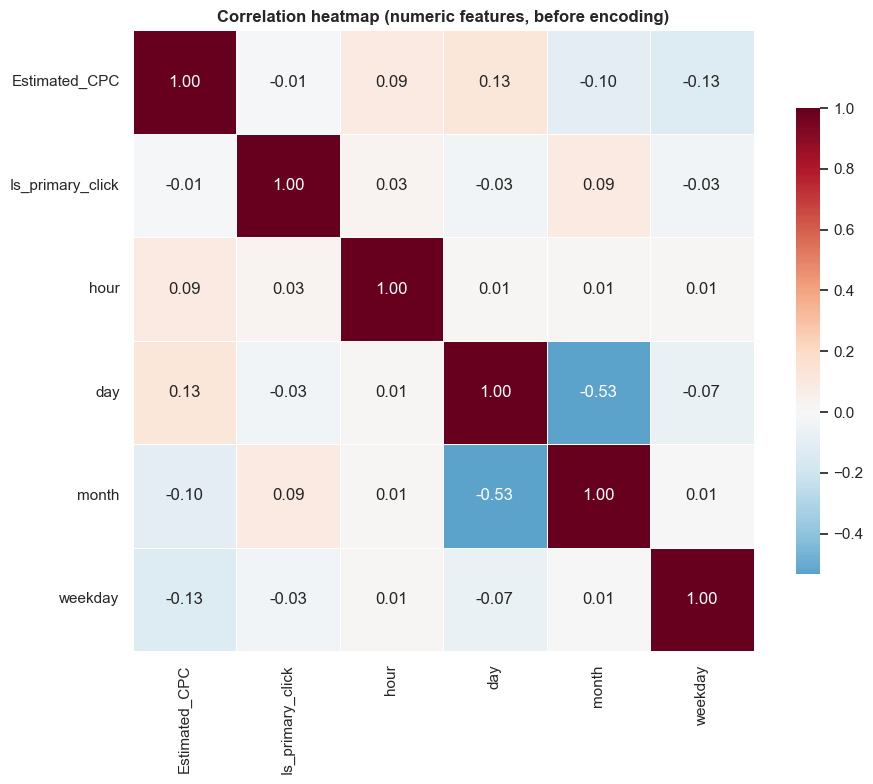

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(ds.select_dtypes(include=[np.number]).corr(),
            annot=True, cmap="RdBu_r", center=0, fmt=".2f",
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.75})
plt.title("Correlation heatmap (numeric features, before encoding)")
plt.tight_layout()
plt.show()


### Pairplot — relationship between variables

The pairplot below is computed on a stratified sample of 2,000 rows to keep runtime reasonable. The full dataset produces the same visual pattern but takes several minutes to render.

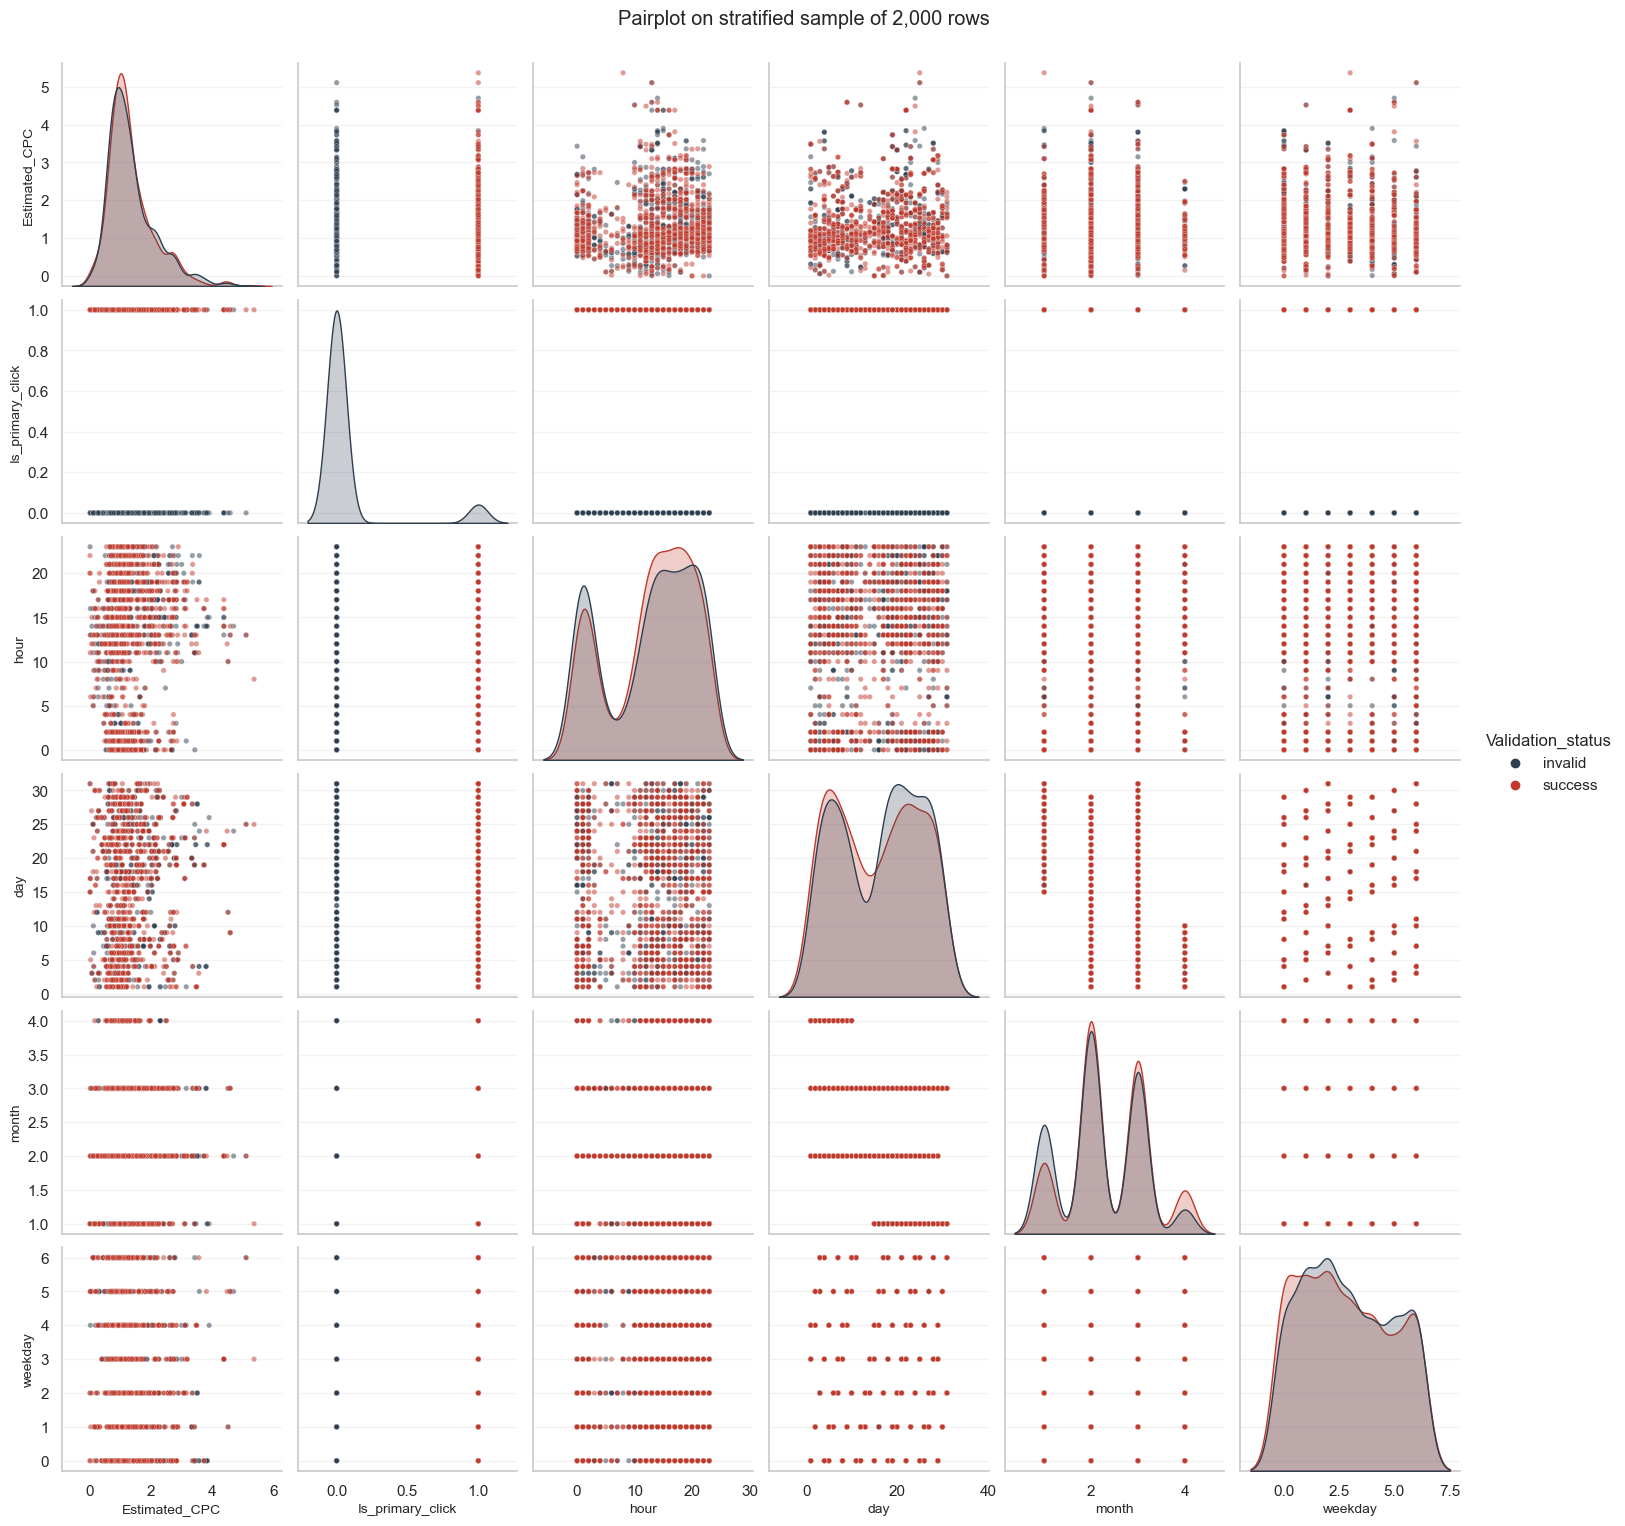

In [15]:
# Stratified sample for the pairplot (full 13k rows would be very slow)
sample = (ds.groupby("Validation_status", group_keys=False)
            .apply(lambda g: g.sample(min(len(g), 1000), random_state=RANDOM_STATE)))

sns.pairplot(sample, hue="Validation_status", diag_kind="kde",
             palette=PALETTE, plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("Pairplot on stratified sample of 2,000 rows", y=1.02)
plt.show()


# Data Preparation

## Data cleaning

Rows where `Device_type`, `Device_platform` or `Connection_type` are `(not set)` are removed. These rows carry almost no signal beyond "unknown" and skew the categorical distributions.

In [16]:
before = len(ds)
ds = ds.loc[ds["Device_type"]     != "(not set)"]
ds = ds.loc[ds["Device_platform"] != "(not set)"]
ds = ds.loc[ds["Connection_type"] != "(not set)"]
after = len(ds)
print(f"Rows before: {before}, after cleaning: {after} (removed {before-after})")


Rows before: 13098, after cleaning: 12834 (removed 264)


## Pre-processing — grouping rare categories

`Device_platform`, `Device_browser_language` and `Device_browser` have long tails of very rare values. Grouping categories with fewer than N records into "Outros" keeps the model from over-fitting to individual rare labels.

In [17]:
# Group rare Device_platform values into "Outros"
limiar = 100
contagem_platform = ds["Device_platform"].value_counts()
platforms_para_agrupar = contagem_platform[contagem_platform < limiar].index
ds["Device_platform_agrupado"] = ds["Device_platform"].apply(
    lambda x: "Outros" if x in platforms_para_agrupar else x
)
print(ds["Device_platform_agrupado"].value_counts())
ds.drop(columns=["Device_platform"], inplace=True)


Android    10602
iOS         1544
Windows      599
Outros        89
Name: Device_platform_agrupado, dtype: int64


In [18]:
# Group rare Device_browser_language values into "Outros"
limiar = 100
contagem_language = ds["Device_browser_language"].value_counts()
language_para_agrupar = contagem_language[contagem_language < limiar].index
ds["Device_browser_language_agrupado"] = ds["Device_browser_language"].apply(
    lambda x: "Outros" if x in language_para_agrupar else x
)
print(ds["Device_browser_language_agrupado"].value_counts())
ds.drop(columns=["Device_browser_language"], inplace=True)


pt           11951
(not set)      671
en             157
Outros          55
Name: Device_browser_language_agrupado, dtype: int64


In [19]:
# Group rare Device_browser values into "Outros" (higher threshold: 500)
limiar = 500
contagem_browser = ds["Device_browser"].value_counts()
browser_para_agrupar = contagem_browser[contagem_browser < limiar].index
ds["Device_browser_agrupado"] = ds["Device_browser"].apply(
    lambda x: "Outros" if x in browser_para_agrupar else x
)
print(ds["Device_browser_agrupado"].value_counts())
ds.drop(columns=["Device_browser"], inplace=True)


Chrome Mobile      5472
Outros             2404
Facebook           2349
Mobile Safari       780
Instagram App       681
Chrome              609
Samsung Browser     539
Name: Device_browser_agrupado, dtype: int64


## Feature engineering

Fraud rarely shows up in a single row. It shows up in aggregate: many clicks from the same IP or the same user in a short window. Two count features capture this pattern and turn out to be strong predictors, alongside `Is_primary_click` which is already in the raw data.

In [20]:
# Clicks per IP
ds["Clicks_per_IP"] = ds.groupby("IP_address")["IP_address"].transform("count")
print(ds[["Clicks_per_IP"]].head())


   Clicks_per_IP
0              1
1              1
2              1
3              1
4              2


In [21]:
# Clicks per User_ID
ds["Clicks_per_User_ID"] = ds.groupby("User_ID")["User_ID"].transform("count")
print(ds[["Clicks_per_User_ID"]].head())


   Clicks_per_User_ID
0                   1
1                   1
2                   1
3                   1
4                   2


In [22]:
# User_ID has served its purpose (creating Clicks_per_User_ID)
ds.drop(columns=["User_ID"], inplace=True)


## Categorical encoding

In [23]:
# Encode target (success -> 0, invalid -> 1)
ds["Validation_status"] = ds["Validation_status"].map({"success": 0, "invalid": 1})
ds["Validation_status"].value_counts()


0    10045
1     2789
Name: Validation_status, dtype: int64

In [24]:
# Label encoding for categorical features
categorical_cols_label = [
    "Campaign_type", "Device_type", "Device_platform_agrupado", "Network",
    "Client", "Connection_type",
    "Device_browser_language_agrupado", "Device_browser_agrupado",
]

for col in categorical_cols_label:
    if ds[col].dtype == "object":
        ds[col] = LabelEncoder().fit_transform(ds[col].astype(str))


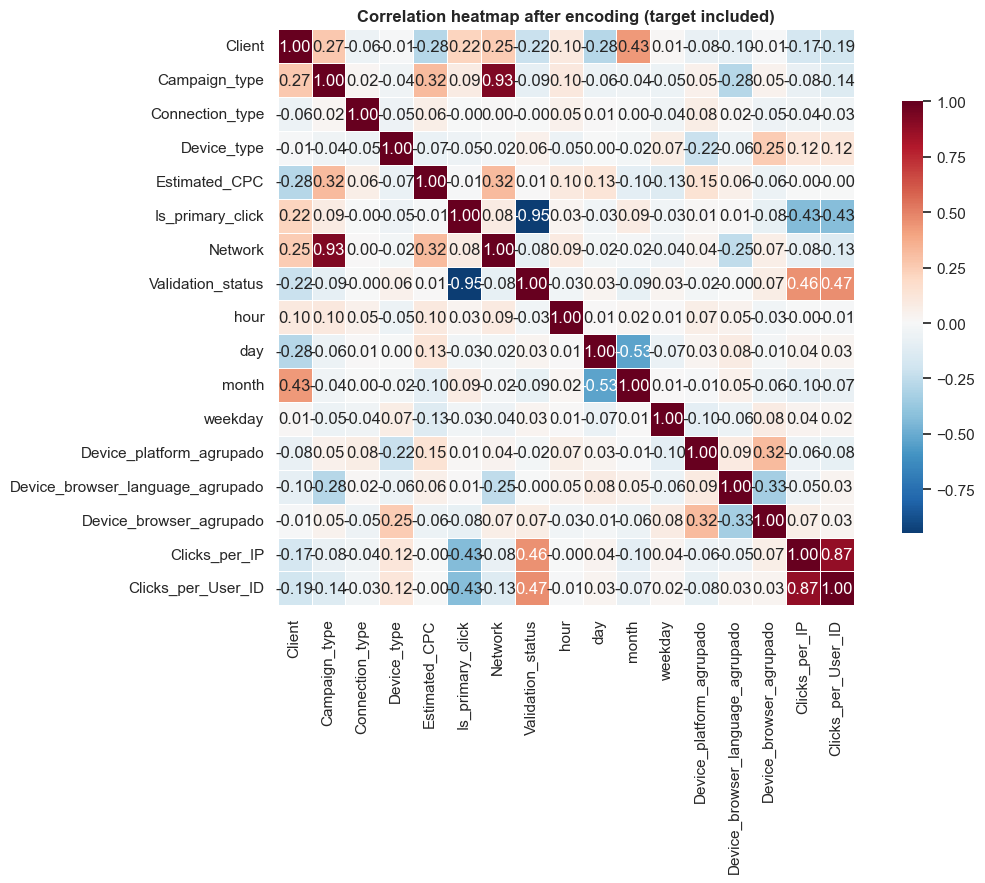

In [25]:
# Correlation heatmap after encoding — includes the target
plt.figure(figsize=(12, 9))
sns.heatmap(ds.select_dtypes(include=[np.number]).corr(),
            annot=True, cmap="RdBu_r", center=0, fmt=".2f",
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.75})
plt.title("Correlation heatmap after encoding (target included)")
plt.tight_layout()
plt.show()


The three strongest correlations with the target `Validation_status` are:

- `Is_primary_click` at -0.95 (near-perfect inverse relationship: primary clicks are almost always legitimate).
- `Clicks_per_User_ID` at 0.47 and `Clicks_per_IP` at 0.46 (users or IPs generating many clicks are strongly linked to fraud).

`Estimated_CPC` and the temporal features stay close to zero — no linear signal there.

Two redundancy patterns to prune:

- `Device_browser_agrupado` correlates strongly with `Device_platform_agrupado` (0.32) — only one is kept.
- `Campaign_type` correlates strongly with `Network` (0.93) — only `Network` is kept.
- `Device_browser_language_agrupado` is dropped because most values are `not set` after grouping and it adds no discriminative signal.


In [26]:
# Drop redundant columns identified above
ds.drop(["Device_browser_agrupado", "Timestamp",
         "Device_browser_language_agrupado", "Campaign_type"],
        axis=1, inplace=True, errors="ignore")


In [27]:
ds.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Client,12834.0,NaN,NaN,NaN,0.55314,0.497187,0.0,0.0,1.0,1.0,1.0
Connection_type,12834.0,NaN,NaN,NaN,0.198301,0.459055,0.0,0.0,0.0,0.0,3.0
Device_type,12834.0,NaN,NaN,NaN,0.982702,0.297023,0.0,1.0,1.0,1.0,3.0
Estimated_CPC,12834.0,NaN,NaN,NaN,1.311131,0.741319,0.0,0.83,1.11,1.58,6.0
IP_address,12834,9156,201.77.102.146,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is_primary_click,12834.0,NaN,NaN,NaN,0.799984,0.400027,0.0,1.0,1.0,1.0,1.0
Network,12834.0,NaN,NaN,NaN,1.198847,1.28082,0.0,0.0,1.0,2.0,4.0
Validation_status,12834.0,NaN,NaN,NaN,0.217313,0.412434,0.0,0.0,0.0,0.0,1.0
hour,12834.0,NaN,NaN,NaN,12.880162,7.374899,0.0,8.0,14.0,19.0,23.0
day,12834.0,NaN,NaN,NaN,15.50039,9.116639,1.0,7.0,17.0,23.0,31.0


# Modeling

## Dataset split

Stratified split into 70% train, 15% validation, 15% test. `IP_address` is preserved separately so flagged IPs can be traced back after prediction.

In [28]:
# Modeling dataset
X = ds.copy(deep=True)

# Preserve the original IPs indexed
original_ips = X[["IP_address"]].copy()
X = X.drop(columns=["IP_address"])

# Target
y = X["Validation_status"]

# 70% train / 15% validation / 15% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15/0.85,
    stratify=y_train_val, random_state=RANDOM_STATE
)

# Remove target from features
X_train = X_train.drop(["Validation_status"], axis=1)
X_val   = X_val.drop(["Validation_status"], axis=1)
X_test  = X_test.drop(["Validation_status"], axis=1)

print(f"Train: {X_train.shape[0]} rows  ({y_train.mean():.1%} positive)")
print(f"Val:   {X_val.shape[0]} rows  ({y_val.mean():.1%} positive)")
print(f"Test:  {X_test.shape[0]} rows  ({y_test.mean():.1%} positive)")


Train: 8983 rows  (21.7% positive)
Val:   1925 rows  (21.7% positive)
Test:  1926 rows  (21.8% positive)


In [29]:
# MinMax scaling — fit only on training data
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


Distribution of classes after SMOTE: Counter({0: 7031, 1: 7031})


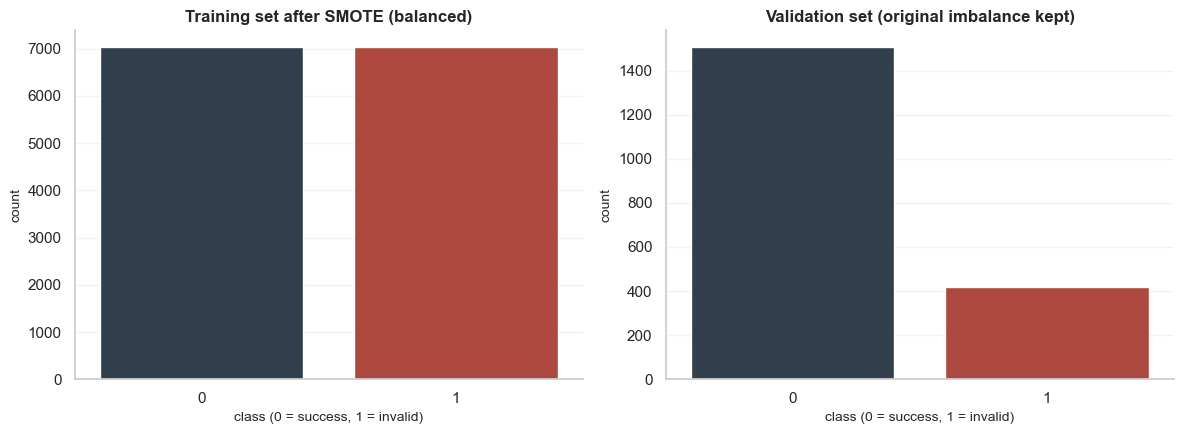

In [30]:
# SMOTE applied only on the training set (never on validation/test)
sm = SMOTE(random_state=RANDOM_STATE, sampling_strategy="auto")
X_train_scaled, y_train = sm.fit_resample(X_train_scaled, y_train)

print("Distribution of classes after SMOTE:", collections.Counter(y_train))

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(x=y_train, ax=axs[0], palette=PALETTE)
axs[0].set_title("Training set after SMOTE (balanced)")
axs[0].set_xlabel("class (0 = success, 1 = invalid)")
axs[0].set_ylabel("count")

sns.countplot(x=y_val, ax=axs[1], palette=PALETTE)
axs[1].set_title("Validation set (original imbalance kept)")
axs[1].set_xlabel("class (0 = success, 1 = invalid)")
axs[1].set_ylabel("count")

plt.tight_layout()
plt.show()


### Reusable helper functions

The same three helper functions are used for every model below: metrics table across train / validation / test, ROC and precision-recall curves on the test set, and feature importance.

In [31]:
FEATURE_NAMES = X_train.columns.tolist()

def calculate_metrics(y_true, y_pred, y_proba=None):
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred)
    auc       = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    return accuracy, precision, recall, f1, auc

def report_train_val_test(model, name):
    """Return a DataFrame with train / validation / test metrics."""
    results = {"Measure": ["ACCURACY", "PRECISION", "RECALL", "F1 SCORE", "AUC"]}
    for split_name, Xs, ys in [
        ("Train", X_train_scaled, y_train),
        ("Validation", X_val_scaled, y_val),
        ("Test", X_test_scaled, y_test),
    ]:
        preds = model.predict(Xs)
        probs = model.predict_proba(Xs)[:, 1]
        results[split_name] = calculate_metrics(ys, preds, probs)
    df = pd.DataFrame(results)
    print(f"\n=== {name} ===")
    print(df.to_string(index=False))
    return df

def plot_roc_pr(model, name):
    probs = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    prec, rec, _ = precision_recall_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ap  = average_precision_score(y_test, probs)

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].plot(fpr, tpr, color=GENUINE_COLOR, linewidth=2, label=f"AUC = {auc:.3f}")
    ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate",
              title=f"ROC — {name}")
    ax[0].legend(frameon=False, loc="lower right")

    ax[1].plot(rec, prec, color=FRAUD_COLOR, linewidth=2, label=f"AP = {ap:.3f}")
    ax[1].set(xlabel="Recall", ylabel="Precision",
              title=f"Precision-Recall — {name}")
    ax[1].legend(frameon=False, loc="lower left")

    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, name, use_permutation=False):
    if use_permutation:
        pi = permutation_importance(model, X_val_scaled, y_val, n_repeats=5,
                                    random_state=RANDOM_STATE, n_jobs=-1)
        importance = pi.importances_mean
    else:
        importance = model.feature_importances_
    df = (pd.DataFrame({"Feature": FEATURE_NAMES, "Importance": importance})
          .sort_values("Importance", ascending=False))
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x="Importance", y="Feature", data=df, color=GENUINE_COLOR)
    ax.bar_label(ax.containers[0], fmt="%.3f", padding=3, fontsize=9)
    plt.title(f"Feature importance — {name}")
    plt.tight_layout()
    plt.show()
    return df

BEST_MODELS = {}


## Support Vector Machine (SVM)

In [32]:
SVM = SVC(gamma="scale", random_state=RANDOM_STATE, probability=True)
SVM.fit(X_train_scaled, y_train)

report_train_val_test(SVM, "SVM (baseline)")



=== SVM (baseline) ===
  Measure    Train  Validation     Test
 ACCURACY 0.962310    0.982857 0.981308
PRECISION 0.991532    0.966102 0.975186
   RECALL 0.932584    0.954545 0.937947
 F1 SCORE 0.961155    0.960289 0.956204
      AUC 0.996920    0.995031 0.995183


,Measure,Train,Validation,Test
0,ACCURACY,0.962310,0.982857,0.981308
1,PRECISION,0.991532,0.966102,0.975186
2,RECALL,0.932584,0.954545,0.937947
3,F1 SCORE,0.961155,0.960289,0.956204
4,AUC,0.996920,0.995031,0.995183


#### Hyperparameter tuning

In [33]:
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf"],
}

grid_search_svm = GridSearchCV(
    estimator=SVC(probability=True, random_state=RANDOM_STATE),
    param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1,
)
grid_search_svm.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search_svm.best_params_)
best_model_svm = grid_search_svm.best_estimator_
BEST_MODELS["SVM"] = best_model_svm


Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


#### Performance after optimization


=== SVM (tuned) ===
  Measure    Train  Validation     Test
 ACCURACY 0.976035    0.976104 0.977155
PRECISION 0.983950    0.928571 0.941176
   RECALL 0.967857    0.964115 0.954654
 F1 SCORE 0.975837    0.946009 0.947867
      AUC 0.997914    0.988002 0.993709


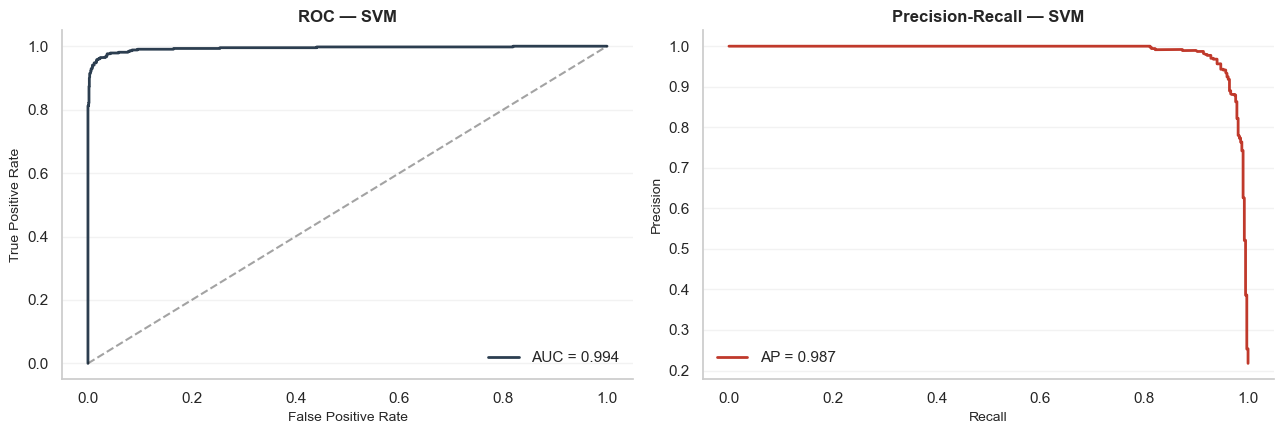

In [34]:
report_train_val_test(best_model_svm, "SVM (tuned)")
plot_roc_pr(best_model_svm, "SVM")


### Feature importance

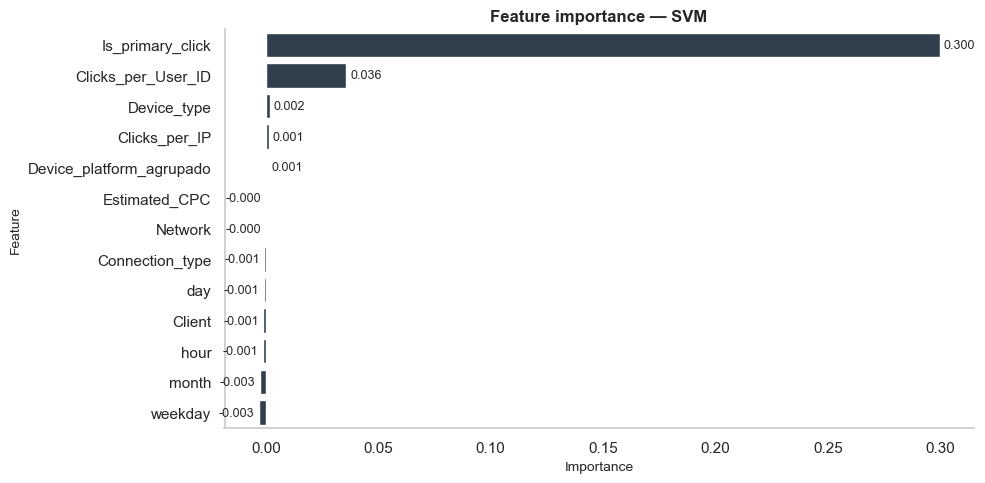

In [35]:
plot_feature_importance(best_model_svm, "SVM", use_permutation=True);

## Random Forest (RF)

In [36]:
RF = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
RF.fit(X_train_scaled, y_train)

report_train_val_test(RF, "Random Forest (baseline)")



=== Random Forest (baseline) ===
  Measure    Train  Validation     Test
 ACCURACY 0.995449    0.980260 0.976116
PRECISION 0.997856    0.956731 0.965087
   RECALL 0.993031    0.952153 0.923628
 F1 SCORE 0.995438    0.954436 0.943902
      AUC 0.999951    0.995946 0.992901


,Measure,Train,Validation,Test
0,ACCURACY,0.995449,0.980260,0.976116
1,PRECISION,0.997856,0.956731,0.965087
2,RECALL,0.993031,0.952153,0.923628
3,F1 SCORE,0.995438,0.954436,0.943902
4,AUC,0.999951,0.995946,0.992901


#### Hyperparameter tuning

In [37]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=1,
)
grid_search_rf.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search_rf.best_params_)
best_model_rf = grid_search_rf.best_estimator_
BEST_MODELS["Random Forest"] = best_model_rf


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


#### Performance after optimization


=== Random Forest (tuned) ===
  Measure    Train  Validation     Test
 ACCURACY 0.994240    0.979740 0.977155
PRECISION 0.997281    0.952267 0.969925
   RECALL 0.991182    0.954545 0.923628
 F1 SCORE 0.994222    0.953405 0.946210
      AUC 0.999921    0.996835 0.994784


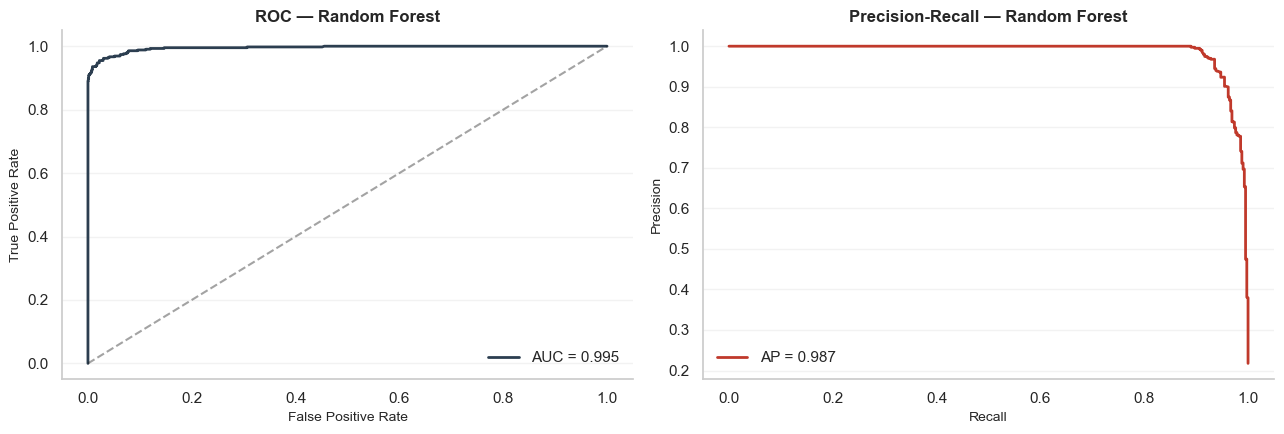

In [38]:
report_train_val_test(best_model_rf, "Random Forest (tuned)")
plot_roc_pr(best_model_rf, "Random Forest")


### Feature importance

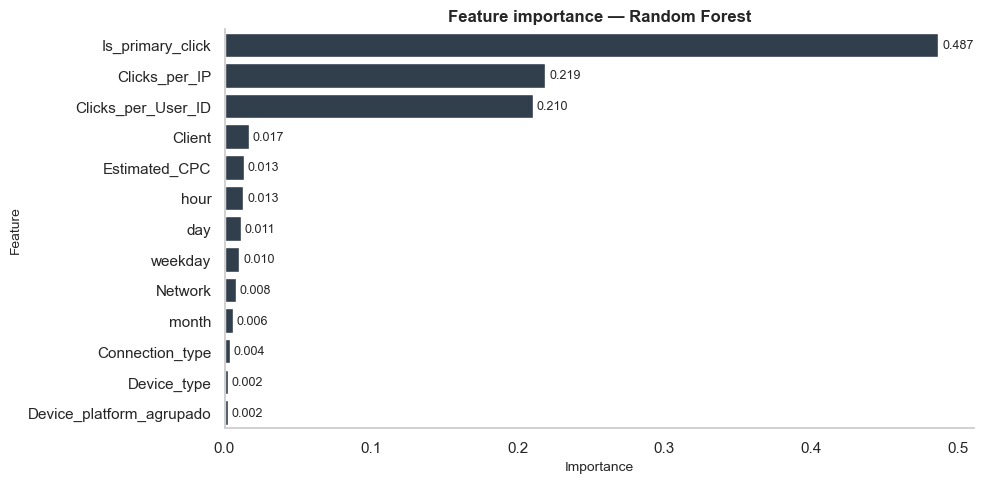

In [39]:
plot_feature_importance(best_model_rf, "Random Forest");

## K-Nearest Neighbors (KNN)

In [40]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train)

report_train_val_test(knn, "KNN (baseline)")



=== KNN (baseline) ===
  Measure    Train  Validation     Test
 ACCURACY 0.985777    0.969351 0.967809
PRECISION 0.984537    0.907029 0.916084
   RECALL 0.987057    0.956938 0.937947
 F1 SCORE 0.985795    0.931315 0.926887
      AUC 0.999340    0.978201 0.981805


,Measure,Train,Validation,Test
0,ACCURACY,0.985777,0.969351,0.967809
1,PRECISION,0.984537,0.907029,0.916084
2,RECALL,0.987057,0.956938,0.937947
3,F1 SCORE,0.985795,0.931315,0.926887
4,AUC,0.999340,0.978201,0.981805


#### Hyperparameter tuning

In [41]:
param_grid_knn = {
    "n_neighbors": range(3, 12),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid_knn, cv=5, scoring="f1", n_jobs=-1,
)
grid_search_knn.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search_knn.best_params_)
best_model_knn = grid_search_knn.best_estimator_
BEST_MODELS["KNN"] = best_model_knn


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}


#### Performance after optimization


=== KNN (tuned) ===
  Measure    Train  Validation     Test
 ACCURACY 0.995306    0.976623 0.976116
PRECISION 0.999283    0.945107 0.965087
   RECALL 0.991324    0.947368 0.923628
 F1 SCORE 0.995288    0.946237 0.943902
      AUC 0.999953    0.977285 0.971718


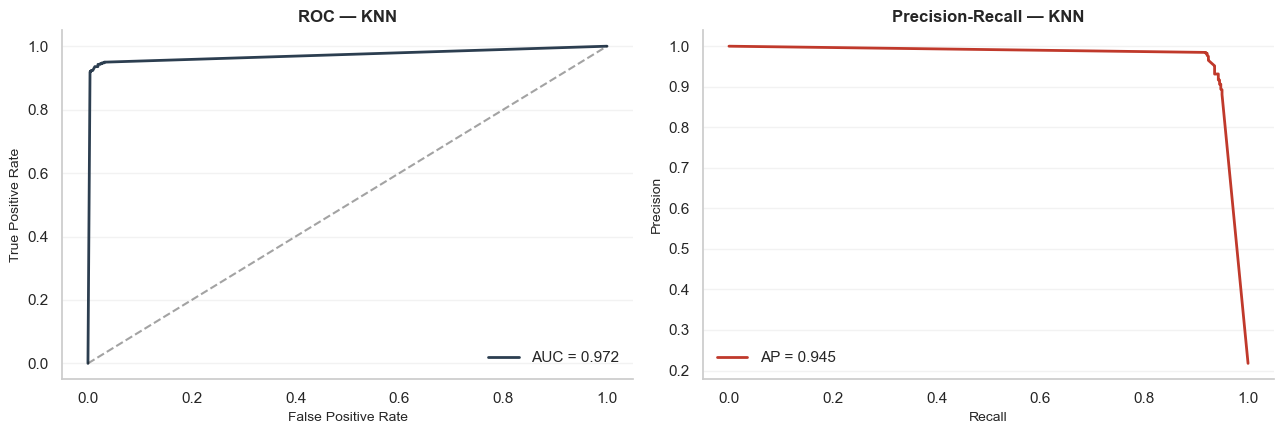

In [42]:
report_train_val_test(best_model_knn, "KNN (tuned)")
plot_roc_pr(best_model_knn, "KNN")


### Feature importance

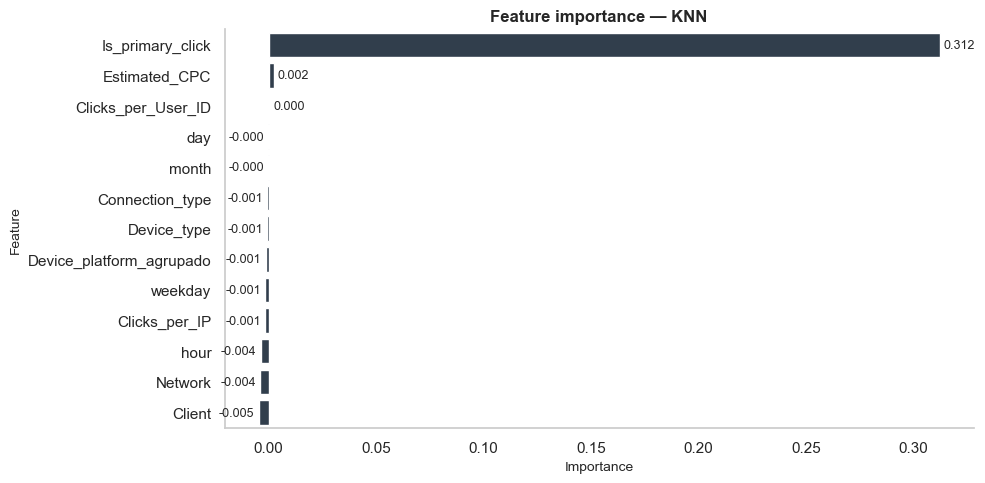

In [43]:
plot_feature_importance(best_model_knn, "KNN", use_permutation=True);

## Gradient Tree Boosting (GTB)

In [44]:
GTB = GradientBoostingClassifier(random_state=RANDOM_STATE)
GTB.fit(X_train_scaled, y_train)

report_train_val_test(GTB, "GTB (baseline)")



=== GTB (baseline) ===
  Measure    Train  Validation     Test
 ACCURACY 0.985706    0.980260 0.978712
PRECISION 0.992075    0.954545 0.965517
   RECALL 0.979235    0.954545 0.935561
 F1 SCORE 0.985613    0.954545 0.950303
      AUC 0.999032    0.998092 0.996112


,Measure,Train,Validation,Test
0,ACCURACY,0.985706,0.980260,0.978712
1,PRECISION,0.992075,0.954545,0.965517
2,RECALL,0.979235,0.954545,0.935561
3,F1 SCORE,0.985613,0.954545,0.950303
4,AUC,0.999032,0.998092,0.996112


#### Hyperparameter tuning

In [45]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.9, 1.0],
}

grid_search_gtb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=1,
)
grid_search_gtb.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search_gtb.best_params_)
best_model_gtb = grid_search_gtb.best_estimator_
BEST_MODELS["Gradient Tree Boosting"] = best_model_gtb


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.9}


#### Performance after optimization


=== GTB (tuned) ===
  Measure    Train  Validation     Test
 ACCURACY 0.992604    0.982338 0.979751
PRECISION 0.998130    0.968293 0.982234
   RECALL 0.987057    0.949761 0.923628
 F1 SCORE 0.992563    0.958937 0.952030
      AUC 0.999750    0.997592 0.996659


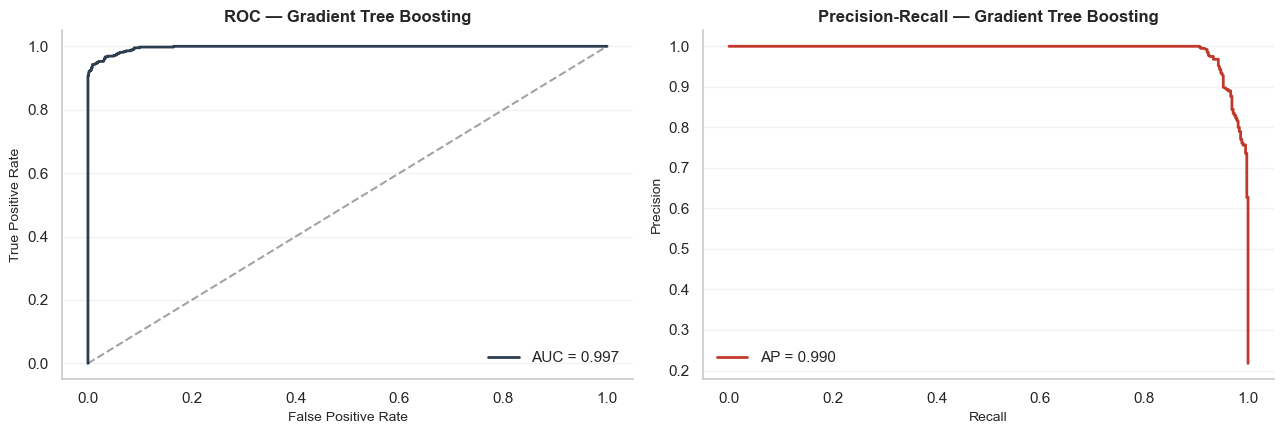

In [46]:
report_train_val_test(best_model_gtb, "GTB (tuned)")
plot_roc_pr(best_model_gtb, "Gradient Tree Boosting")


### Feature importance

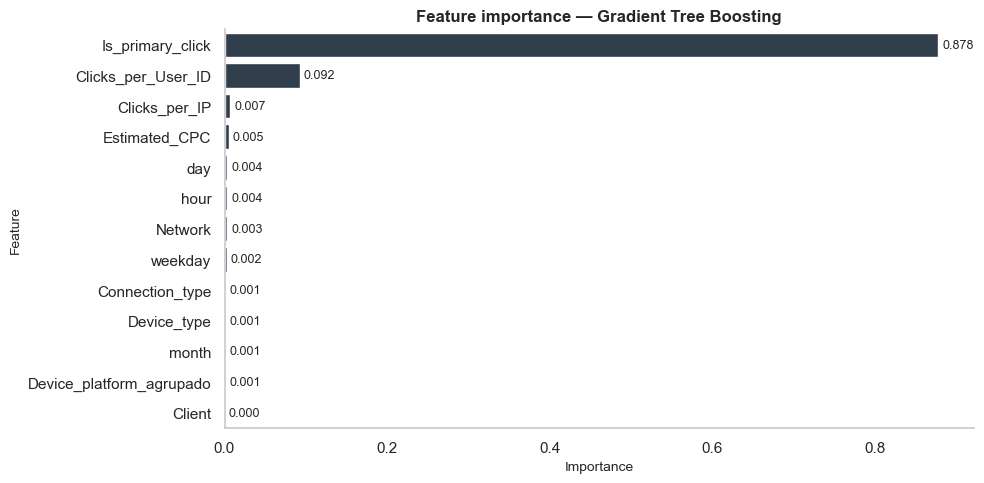

In [47]:
plot_feature_importance(best_model_gtb, "Gradient Tree Boosting");

## XGBoost

In [48]:
XGB = XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1)
XGB.fit(X_train_scaled, y_train)

report_train_val_test(XGB, "XGBoost (baseline)")



=== XGBoost (baseline) ===
  Measure    Train  Validation     Test
 ACCURACY 0.995378    0.978182 0.974559
PRECISION 0.997714    0.947619 0.957921
   RECALL 0.993031    0.952153 0.923628
 F1 SCORE 0.995367    0.949881 0.940462
      AUC 0.999948    0.996635 0.996316


,Measure,Train,Validation,Test
0,ACCURACY,0.995378,0.978182,0.974559
1,PRECISION,0.997714,0.947619,0.957921
2,RECALL,0.993031,0.952153,0.923628
3,F1 SCORE,0.995367,0.949881,0.940462
4,AUC,0.999948,0.996635,0.996316


#### Hyperparameter tuning

In [49]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.7, 1.0],
}

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1),
    param_grid=param_grid_xgb, cv=5, scoring="f1", n_jobs=-1, verbose=1,
)
grid_search_xgb.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search_xgb.best_params_)
best_model_xgb = grid_search_xgb.best_estimator_
BEST_MODELS["XGBoost"] = best_model_xgb


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}


#### Performance after optimization


=== XGBoost (tuned) ===
  Measure    Train  Validation     Test
 ACCURACY 0.992604    0.981818 0.978193
PRECISION 0.996987    0.959233 0.972431
   RECALL 0.988195    0.956938 0.926014
 F1 SCORE 0.992571    0.958084 0.948655
      AUC 0.999758    0.997412 0.996868


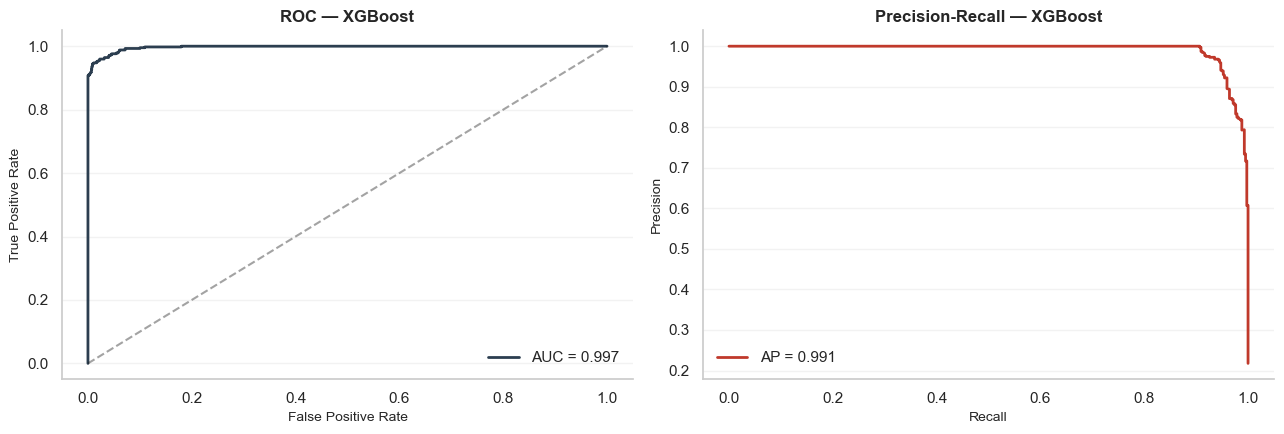

In [50]:
report_train_val_test(best_model_xgb, "XGBoost (tuned)")
plot_roc_pr(best_model_xgb, "XGBoost")


### Feature importance

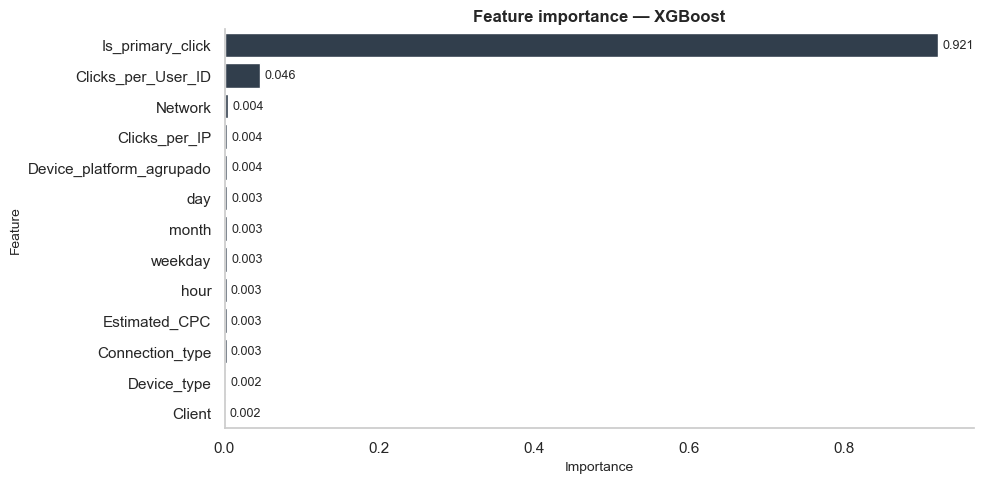

In [51]:
plot_feature_importance(best_model_xgb, "XGBoost");

# Evaluation

## Model comparison

In [52]:
def test_metrics(model):
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    return dict(zip(
        ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"],
        calculate_metrics(y_test, preds, probs),
    ))

performance_df = pd.DataFrame(
    {name: test_metrics(m) for name, m in BEST_MODELS.items()}
).T.round(4)

performance_df


,Accuracy,Precision,Recall,F1 Score,AUC
SVM,0.9772,0.9412,0.9547,0.9479,0.9937
Random Forest,0.9772,0.9699,0.9236,0.9462,0.9948
KNN,0.9761,0.9651,0.9236,0.9439,0.9717
Gradient Tree Boosting,0.9798,0.9822,0.9236,0.9520,0.9967
XGBoost,0.9782,0.9724,0.9260,0.9487,0.9969


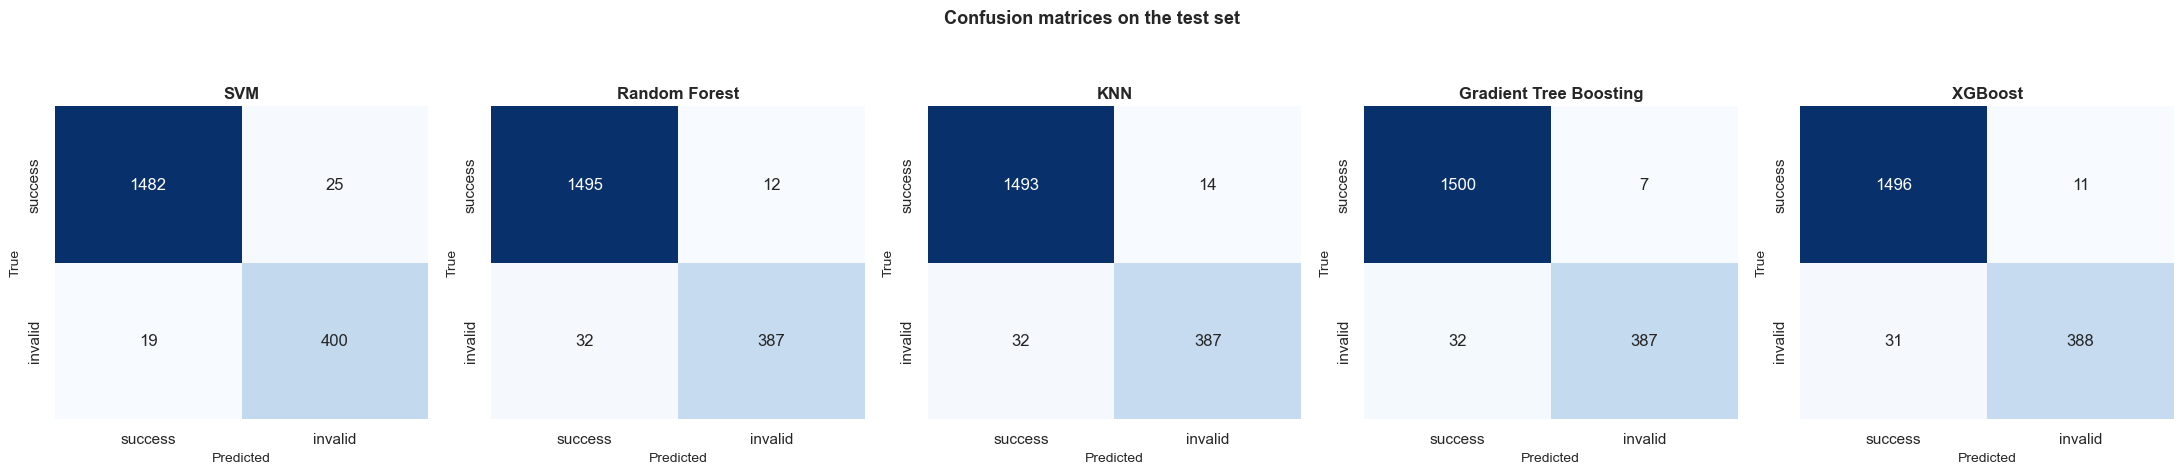

In [53]:
# Confusion matrices — one grid, all 5 models
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for ax, (name, model) in zip(axes, BEST_MODELS.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["success", "invalid"],
                yticklabels=["success", "invalid"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.suptitle("Confusion matrices on the test set", y=1.05, fontsize=13, fontweight="semibold")
plt.tight_layout()
plt.show()


GTB shows the best accuracy (0.9798), precision (0.9822) and F1 (0.9520) across the five tuned models. Recall is a four-way tie at 0.9236 among GTB, RF, KNN and XGBoost, with SVM slightly ahead at 0.9547. The confusion matrix for GTB shows very low counts on both false positives and false negatives, which is exactly what a balanced fraud classifier should look like.

The two error types do not carry the same cost. A false positive means a legitimate click gets added to the exclusion list, which risks losing a real customer. A false negative means a fraudulent click slips through, but Google Ads often refunds those clicks anyway. Because the flagged IP list is reviewed by the agency before being applied (there is no automatic blocking), the cost of a false positive is softened. GTB's combination of highest precision and top-tier recall makes it the safest choice for that review workflow.


# Deployment

## Exporting fraudulent IPs

The chosen model (`best_model_gtb`) scores the test set. Every IP whose click was predicted as invalid is exported, ordered by predicted probability, ready to be reviewed and pushed to the Google Ads exclusion list.

In [54]:
FINAL_MODEL = best_model_gtb

y_pred_final  = FINAL_MODEL.predict(X_test_scaled)
y_proba_final = FINAL_MODEL.predict_proba(X_test_scaled)[:, 1]

original_ips_test = original_ips.loc[X_test.index]
assert original_ips_test.shape[0] == y_pred_final.shape[0]

results = pd.DataFrame({
    "IP_address": original_ips_test["IP_address"].values,
    "prediction": y_pred_final,
    "fraud_probability": y_proba_final,
})

fraudulent_ips = (results[results["prediction"] == 1]
                  .sort_values("fraud_probability", ascending=False)
                  .drop_duplicates(subset="IP_address"))

out_path = REPORT_DIR / "fraudulent_ips.xlsx"
fraudulent_ips.to_excel(out_path, index=False)
print(f"File with {len(fraudulent_ips)} unique fraudulent IPs created: {out_path}")
fraudulent_ips.head(10)


File with 325 unique fraudulent IPs created: ../reports/fraudulent_ips.xlsx


,IP_address,prediction,fraud_probability
722,164.163.31.248,1,0.999994
488,201.77.102.146,1,0.999993
483,2804:14d:32b1:25b7:784d:4d67:4f88:8316,1,0.999990
764,2804:10f8:4327:2e00:f898:3822:f578:20be,1,0.999986
1268,2804:14c:94:2e43:81c8:70da:3f49:1305,1,0.999986
1164,45.169.51.129,1,0.999985
1070,131100139238,1,0.999985
584,2804:868:d040:b06c:c5cb:af9a:a7a1:e029,1,0.999982
401,2804:431:d77d:d874:8c3e:4714:926:f5b9,1,0.999981
1442,2804:18:d2:7ac1:1:0:8c2f:7e99,1,0.999980


## Saving the model

In [55]:
model_path  = MODEL_DIR / "best_model_gtb.joblib"
scaler_path = MODEL_DIR / "minmax_scaler.joblib"

dump(FINAL_MODEL, model_path)
dump(scaler, scaler_path)

print(f"Model saved at: {model_path}")
print(f"Scaler saved at: {scaler_path}")
print("\nTo reuse in another script:")
print(">>> from joblib import load")
print(">>> model  = load('models/best_model_gtb.joblib')")
print(">>> scaler = load('models/minmax_scaler.joblib')")


Model saved at: ../models/best_model_gtb.joblib
Scaler saved at: ../models/minmax_scaler.joblib

To reuse in another script:
>>> from joblib import load
>>> model  = load('models/best_model_gtb.joblib')
>>> scaler = load('models/minmax_scaler.joblib')


---
## Scope and limitations

The ground truth is inherited from the Traffic Guardian tool. The model learns what Traffic Guardian labels as fraud, so a different definition of fraud would require re-labeling.

The sample is restricted to two clients from a single agency across three months (January to March 2024). Generalization to other verticals or time periods was not validated.

Predictions run in batch mode over exported logs. A production system would need integration with the Google Ads API to fetch clicks and push exclusions automatically.

Google Ads already refunds a share of the invalid clicks, which reduces the direct financial impact of fraud. The project therefore stands as an independent auditing layer and a technical demonstration of building a fraud classifier on real, imbalanced data, not as a replacement for the platform's own detection.

Class imbalance is handled with SMOTE. Cost-sensitive learning through `class_weight` or explicit threshold tuning would be a natural next step.
